<a href="https://www.kaggle.com/code/satyambhagat/most-streamed-artist-on-spotify-in-sql?scriptVersionId=341799957" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Imports**

In [1]:
import numpy as np , pandas as pd , matplotlib.pyplot as plt , seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rishavsvault/most-streamed-artists-on-spotify/Most Streamed Artists on Spotify (17_07_2026) V1.1.csv')

# **Exploring**

In [3]:
df.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [4]:
df.drop(index = 0 , inplace = True)

In [5]:
df.isnull().sum()

Artist Name                            0
Sex                                    0
Country of Origin                      0
Primary Language                       0
Primary Genre                          0
 Artist Type                           0
Debut Year                             0
Total Streams (in millions)            0
Lead Streams (in millions)             0
Feature Streams (in millions)          0
Solo Streams (in millions)             0
% of Solo Streams                      0
Collaborative Streams (in millions)    0
% of Collaborative Streams             0
dtype: int64

In [6]:
df.describe()

,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,2005.344689,16575.777555,11975.983768,4605.217635,8234.218236,50.636791,8341.559319,49.363209
std,13.325905,13839.154261,11261.167637,5710.348408,9383.998562,33.791862,9003.504081,33.791862
min,1939.000000,6972.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2001.500000,8756.450000,6487.700000,694.000000,2512.850000,20.035412,2009.300000,16.825528
50%,2009.000000,11879.600000,8691.500000,3001.400000,6435.400000,47.080168,6579.500000,52.919832
75%,2014.000000,17872.050000,13412.950000,6054.550000,10057.900000,83.174472,10972.150000,79.964588
max,2023.000000,127861.000000,126177.300000,43710.500000,113421.500000,100.000000,77012.800000,100.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 1 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          499 non-null    object 
 1   Sex                                  499 non-null    object 
 2   Country of Origin                    499 non-null    object 
 3   Primary Language                     499 non-null    object 
 4   Primary Genre                        499 non-null    object 
 5    Artist Type                         499 non-null    object 
 6   Debut Year                           499 non-null    int64  
 7   Total Streams (in millions)          499 non-null    float64
 8   Lead Streams (in millions)           499 non-null    float64
 9   Feature Streams (in millions)        499 non-null    float64
 10  Solo Streams (in millions)           499 non-null    float64
 11  % of Solo Streams               

In [8]:
for col in df:
    print(col , "has " , df[col].nunique() ,' unique values')

Artist Name has  499  unique values
Sex has  3  unique values
Country of Origin has  43  unique values
Primary Language has  11  unique values
Primary Genre has  23  unique values
 Artist Type has  2  unique values
Debut Year has  61  unique values
Total Streams (in millions) has  498  unique values
Lead Streams (in millions) has  497  unique values
Feature Streams (in millions) has  463  unique values
Solo Streams (in millions) has  493  unique values
% of Solo Streams has  484  unique values
Collaborative Streams (in millions) has  487  unique values
% of Collaborative Streams has  484  unique values


In [9]:
print(f" There are {df.select_dtypes(include = [int ,float]).columns} numeric values")

 There are Index(['Debut Year', 'Total Streams (in millions)',
       'Lead Streams (in millions)', 'Feature Streams (in millions)',
       'Solo Streams (in millions)', '% of Solo Streams',
       'Collaborative Streams (in millions)', '% of Collaborative Streams'],
      dtype='object') numeric values


In [10]:
print(f"There are {df.select_dtypes(include = object).columns} categoric values")

There are Index(['Artist Name', 'Sex', 'Country of Origin', 'Primary Language',
       'Primary Genre', ' Artist Type'],
      dtype='object') categoric values


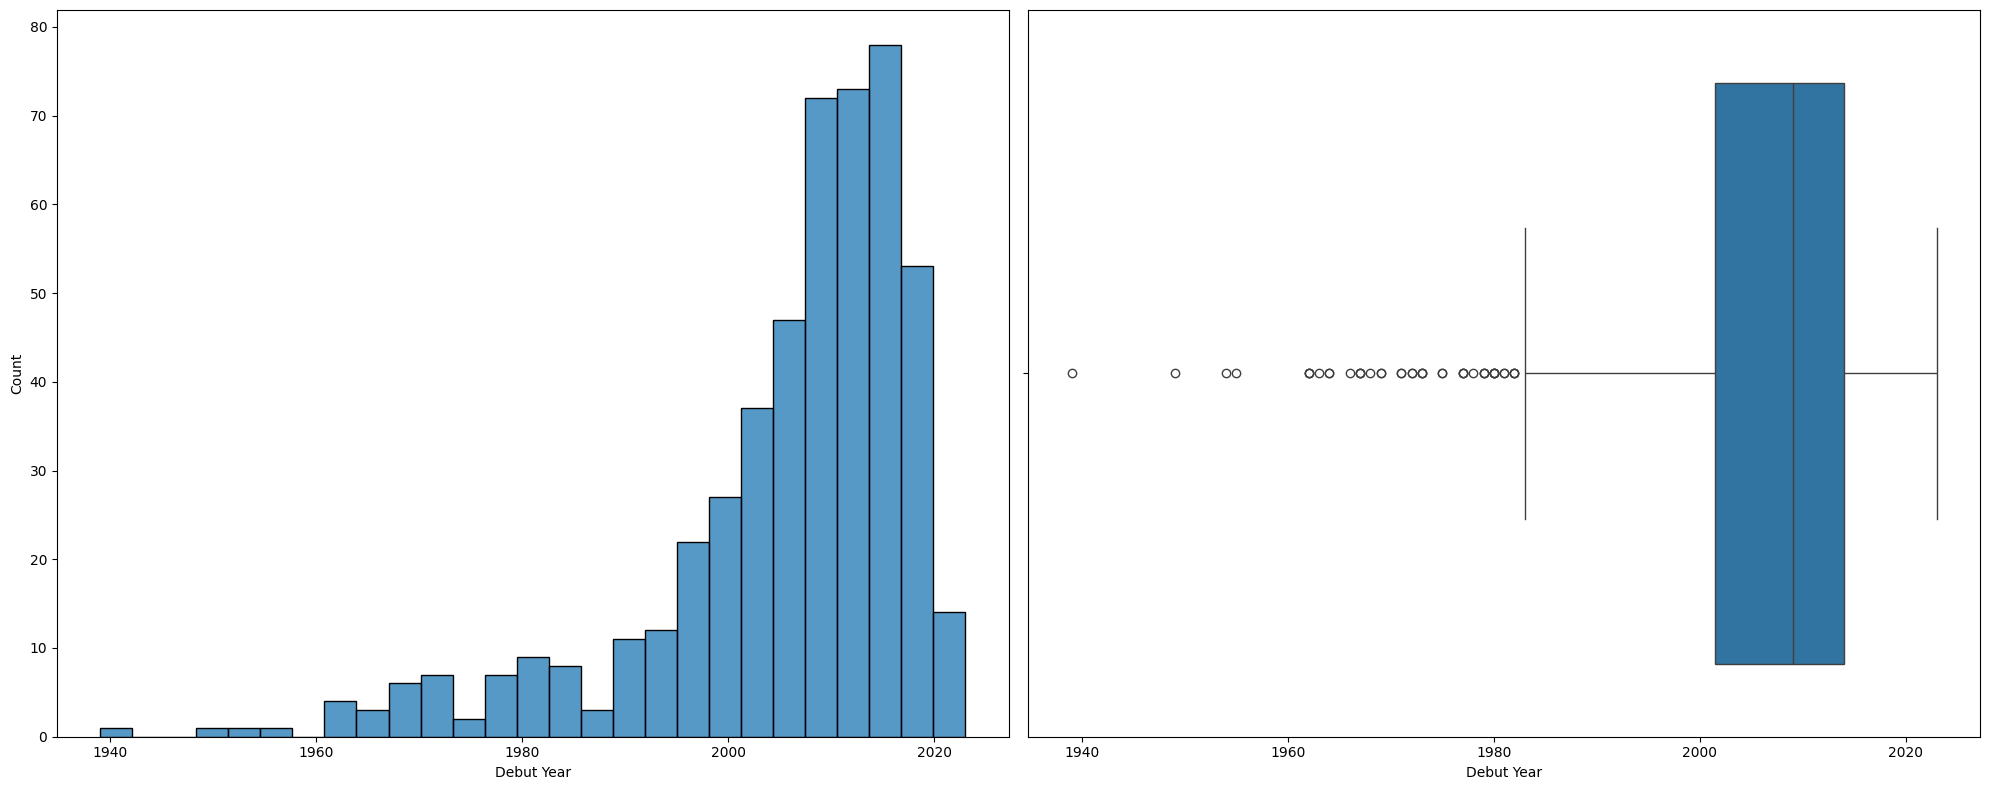

Unique vales 61
Missing values in Debut Year 0


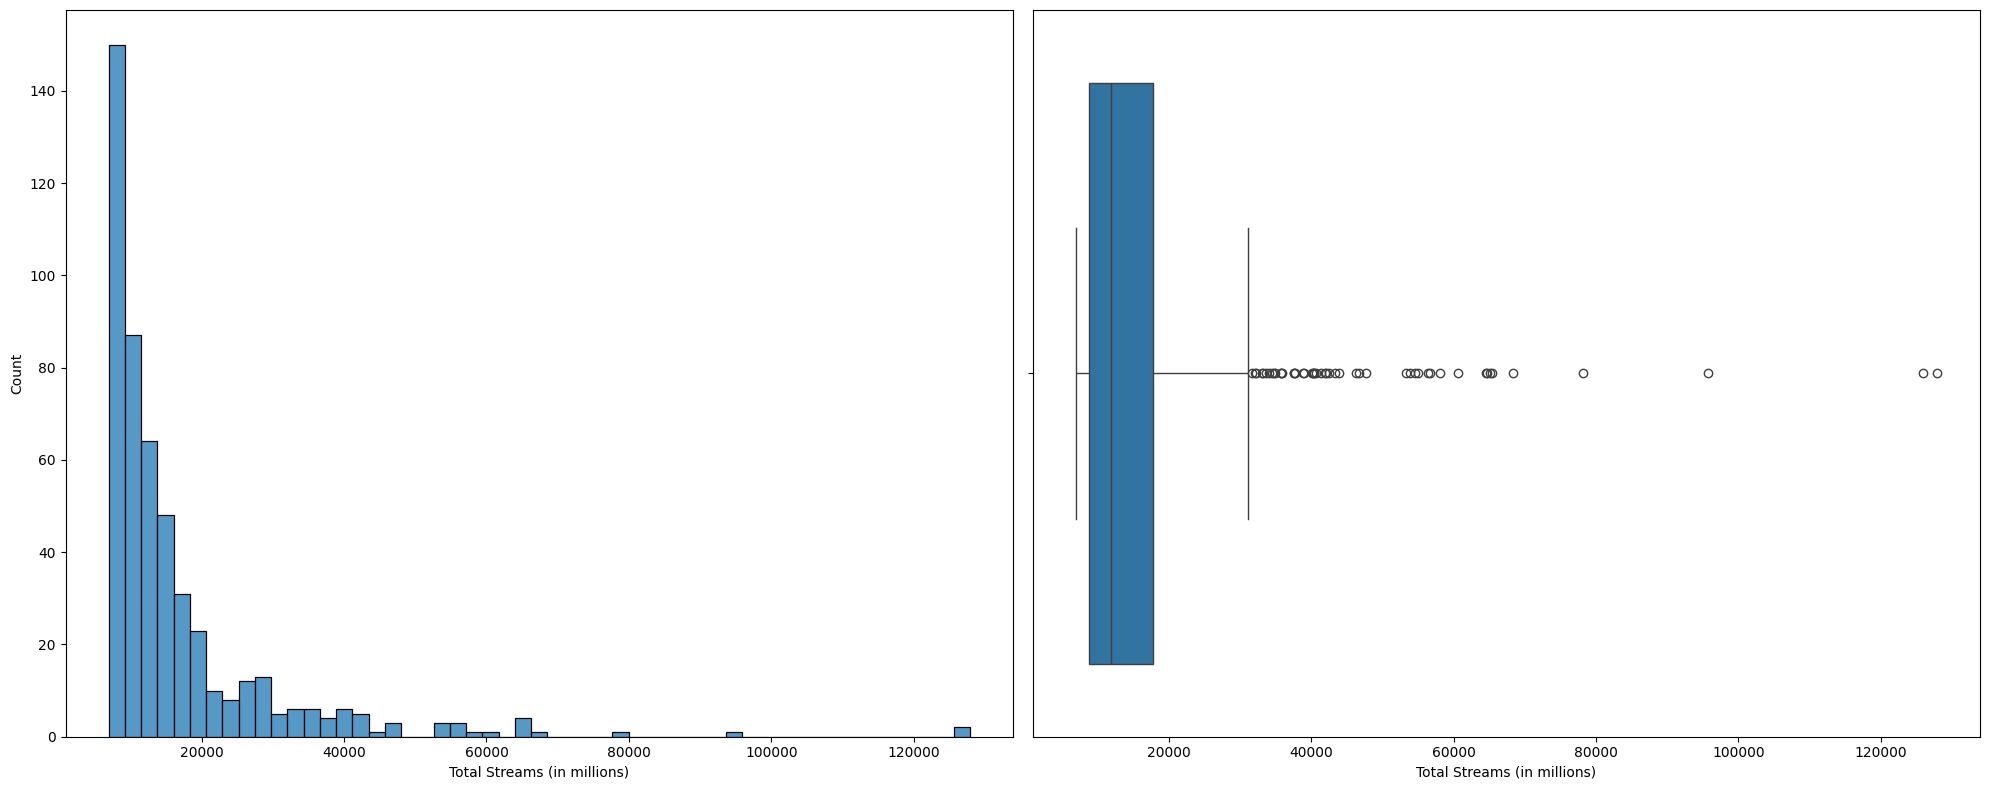

Unique vales 498
Missing values in Total Streams (in millions) 0


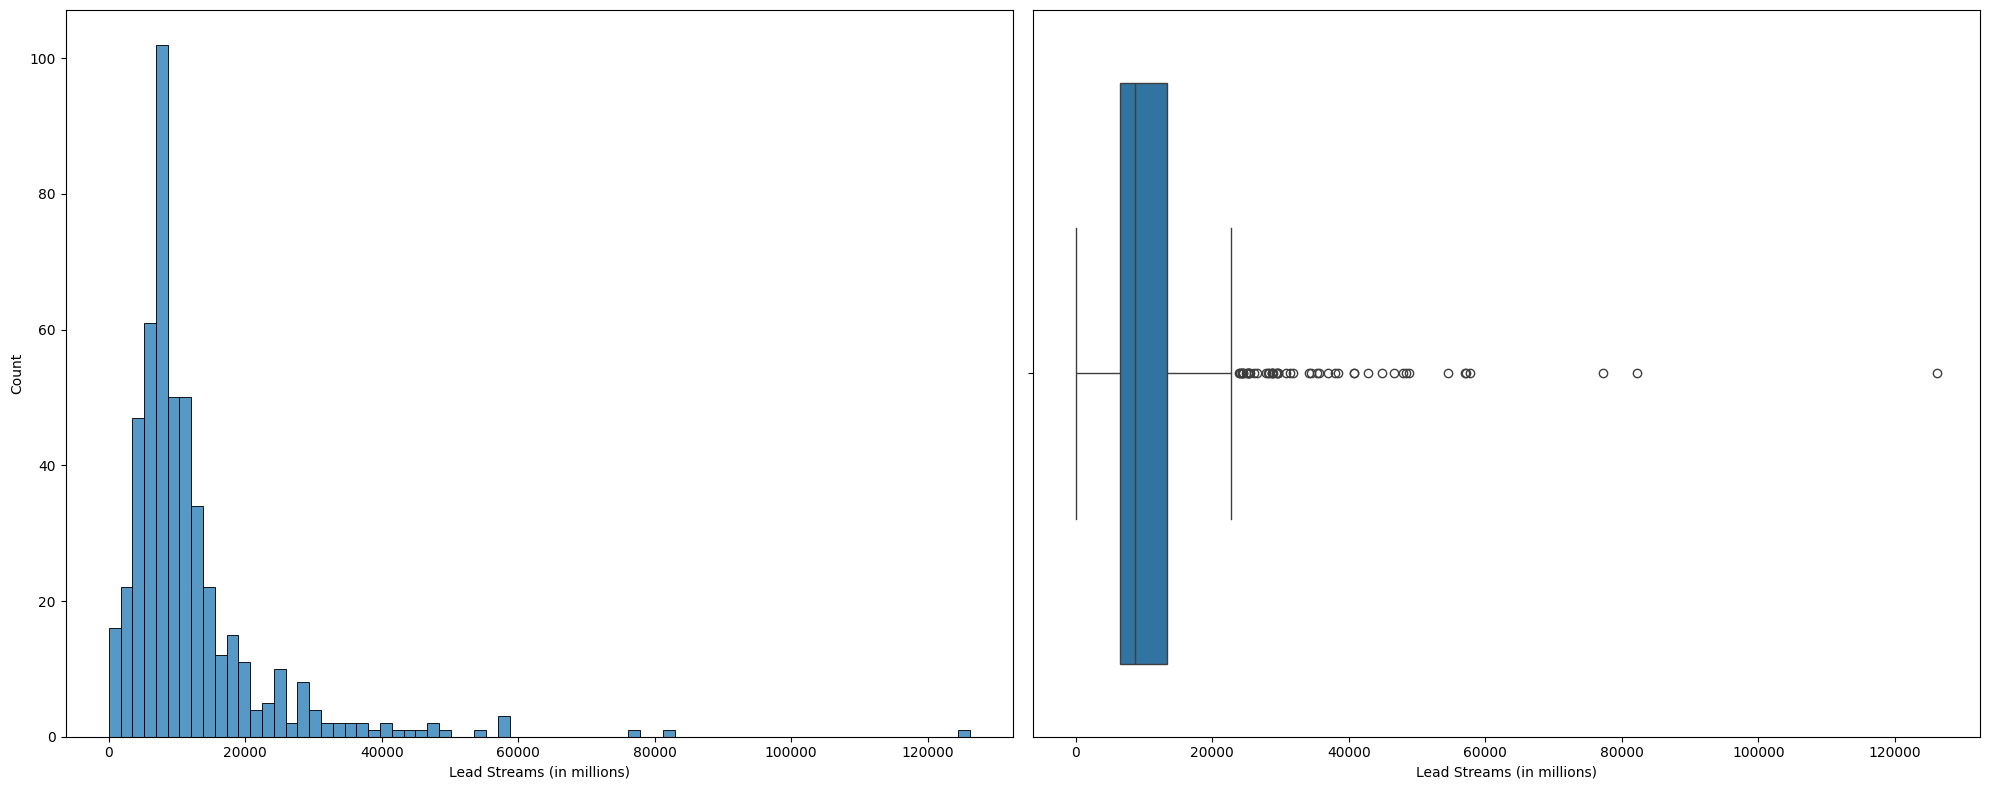

Unique vales 497
Missing values in Lead Streams (in millions) 0


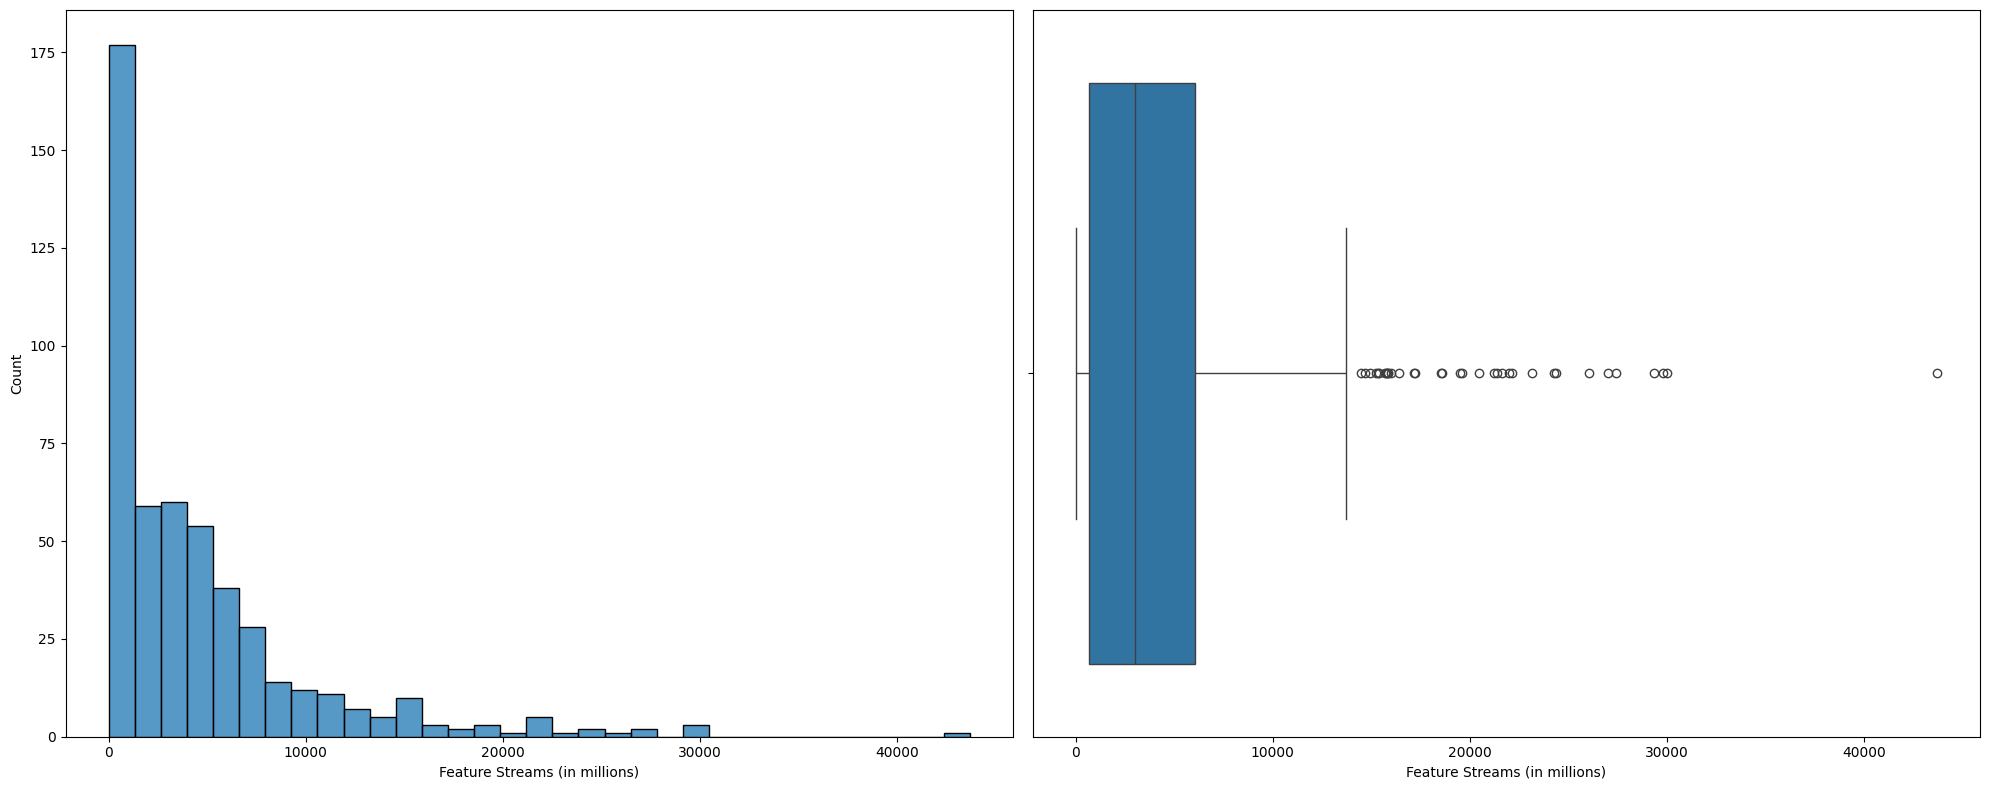

Unique vales 463
Missing values in Feature Streams (in millions) 0


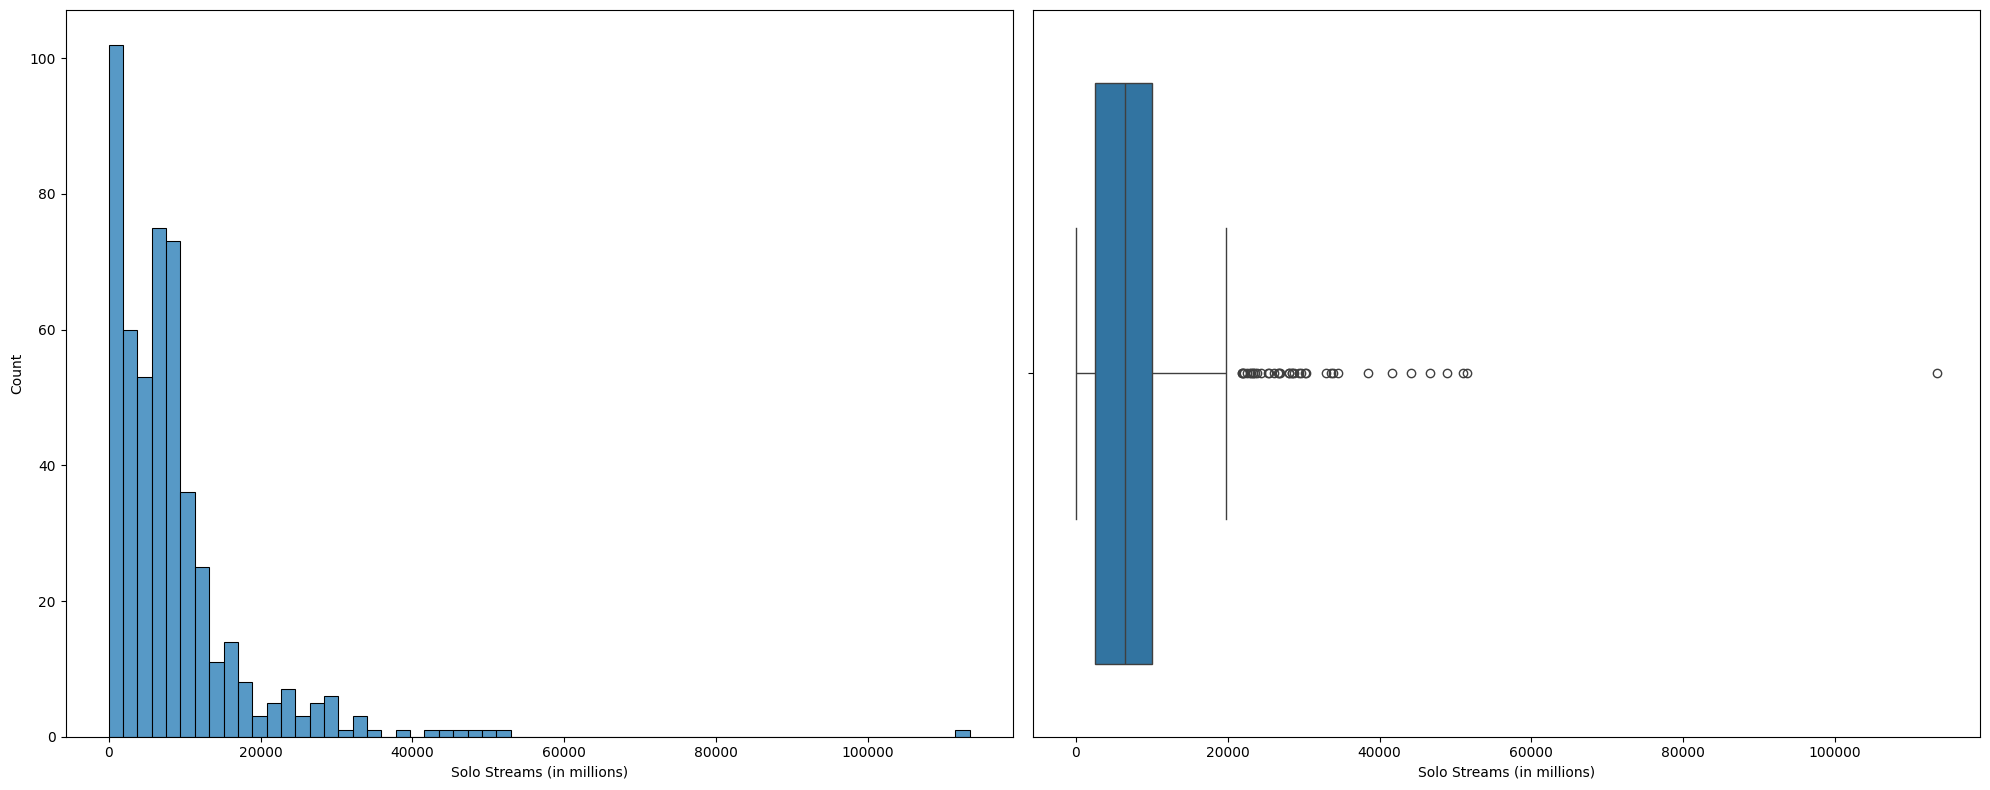

Unique vales 493
Missing values in Solo Streams (in millions) 0


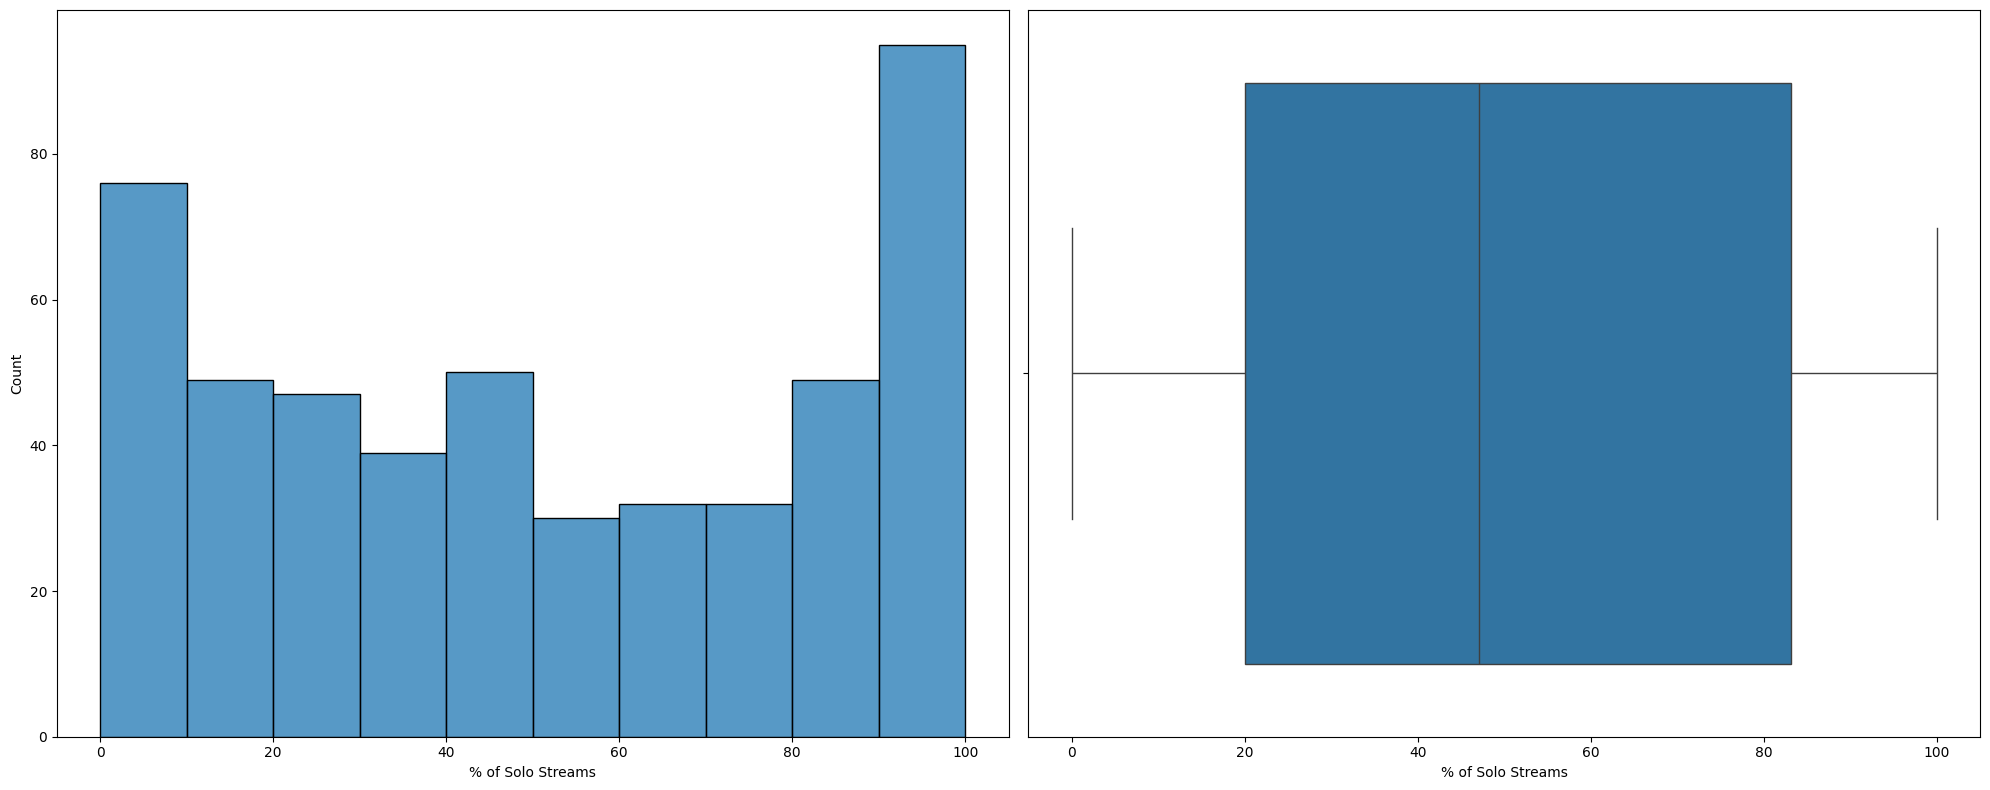

Unique vales 484
Missing values in % of Solo Streams 0


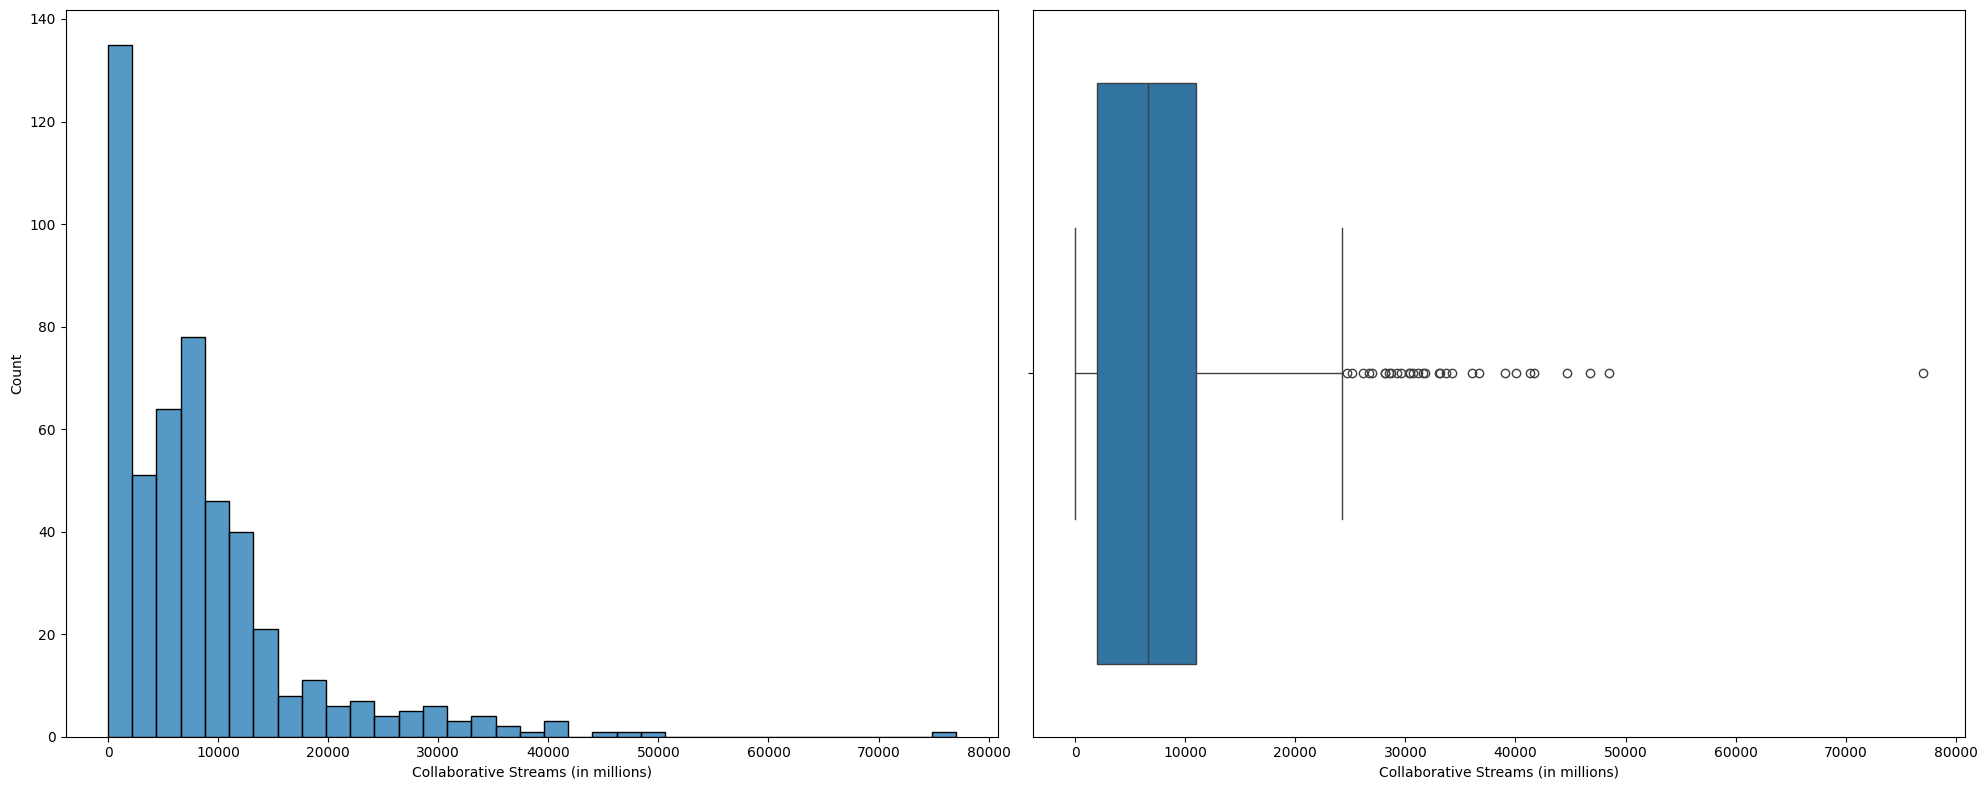

Unique vales 487
Missing values in Collaborative Streams (in millions) 0


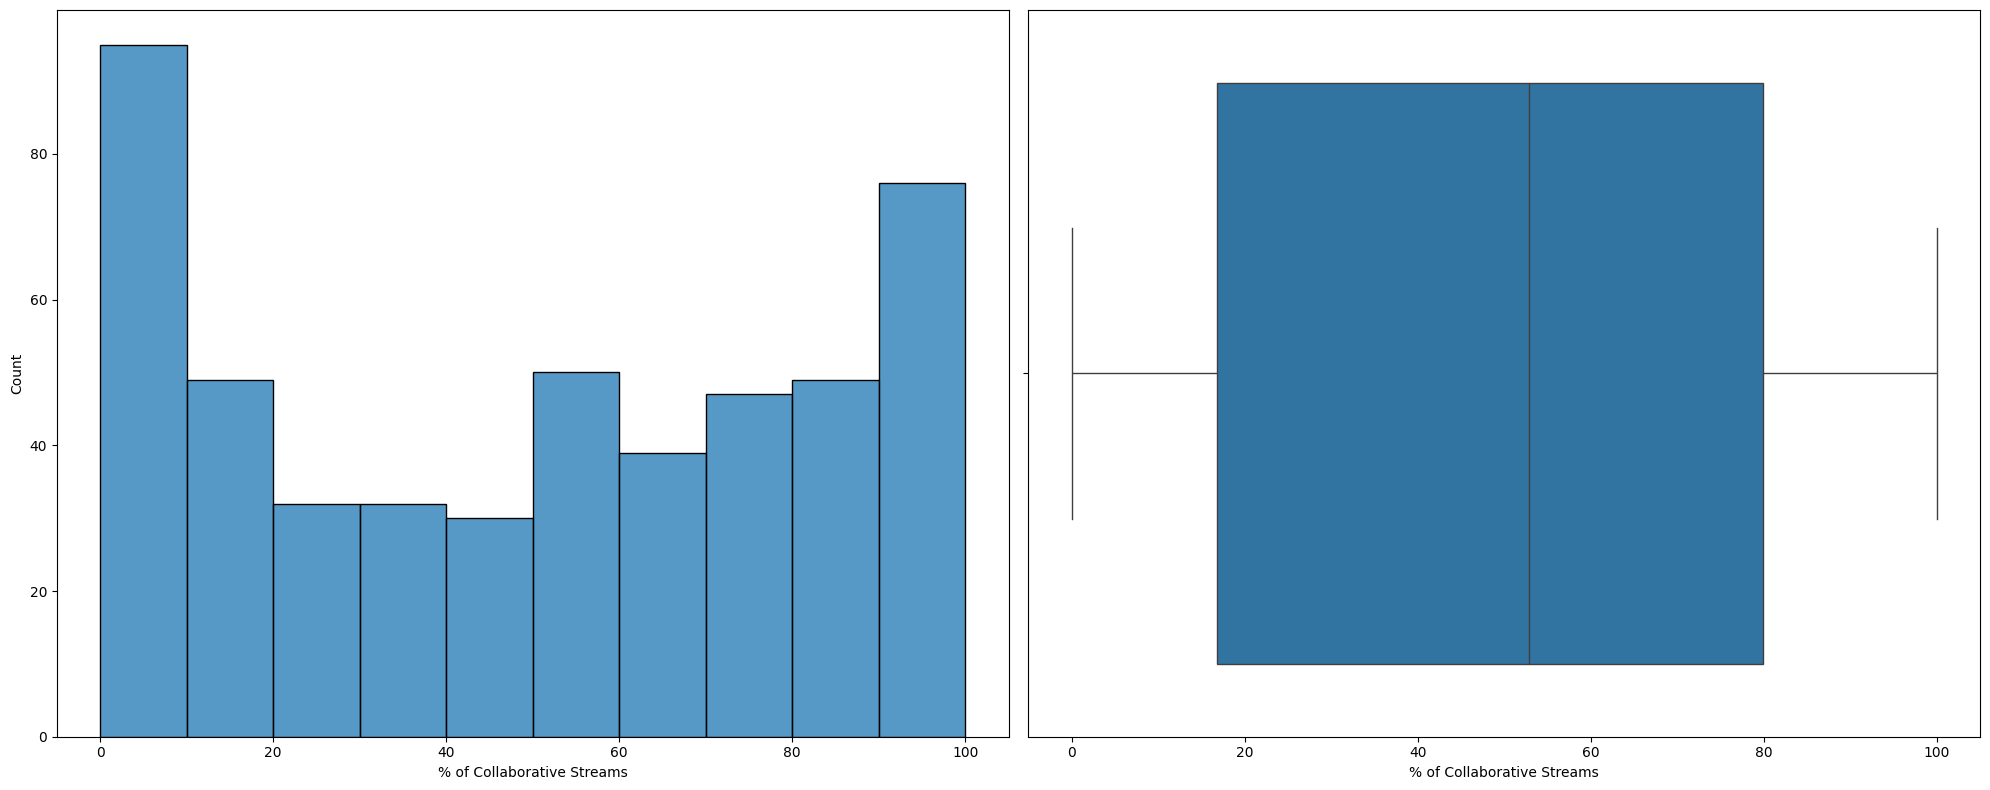

Unique vales 484
Missing values in % of Collaborative Streams 0


In [11]:
numeric = ['Debut Year', 'Total Streams (in millions)',
       'Lead Streams (in millions)', 'Feature Streams (in millions)',
       'Solo Streams (in millions)', '% of Solo Streams',
       'Collaborative Streams (in millions)', '% of Collaborative Streams']
for num in numeric : 
    plt.figure(figsize = (20,8))
    plt.subplot(1,2,1)
    sns.histplot(x = num ,data = df)
    plt.subplot(1,2,2)
    sns.boxplot(x = num ,data = df)
    plt.tight_layout()
    plt.show()
    print("Unique vales" , df[num].nunique())
    print(f"Missing values in {num}" , df[num].isna().sum())

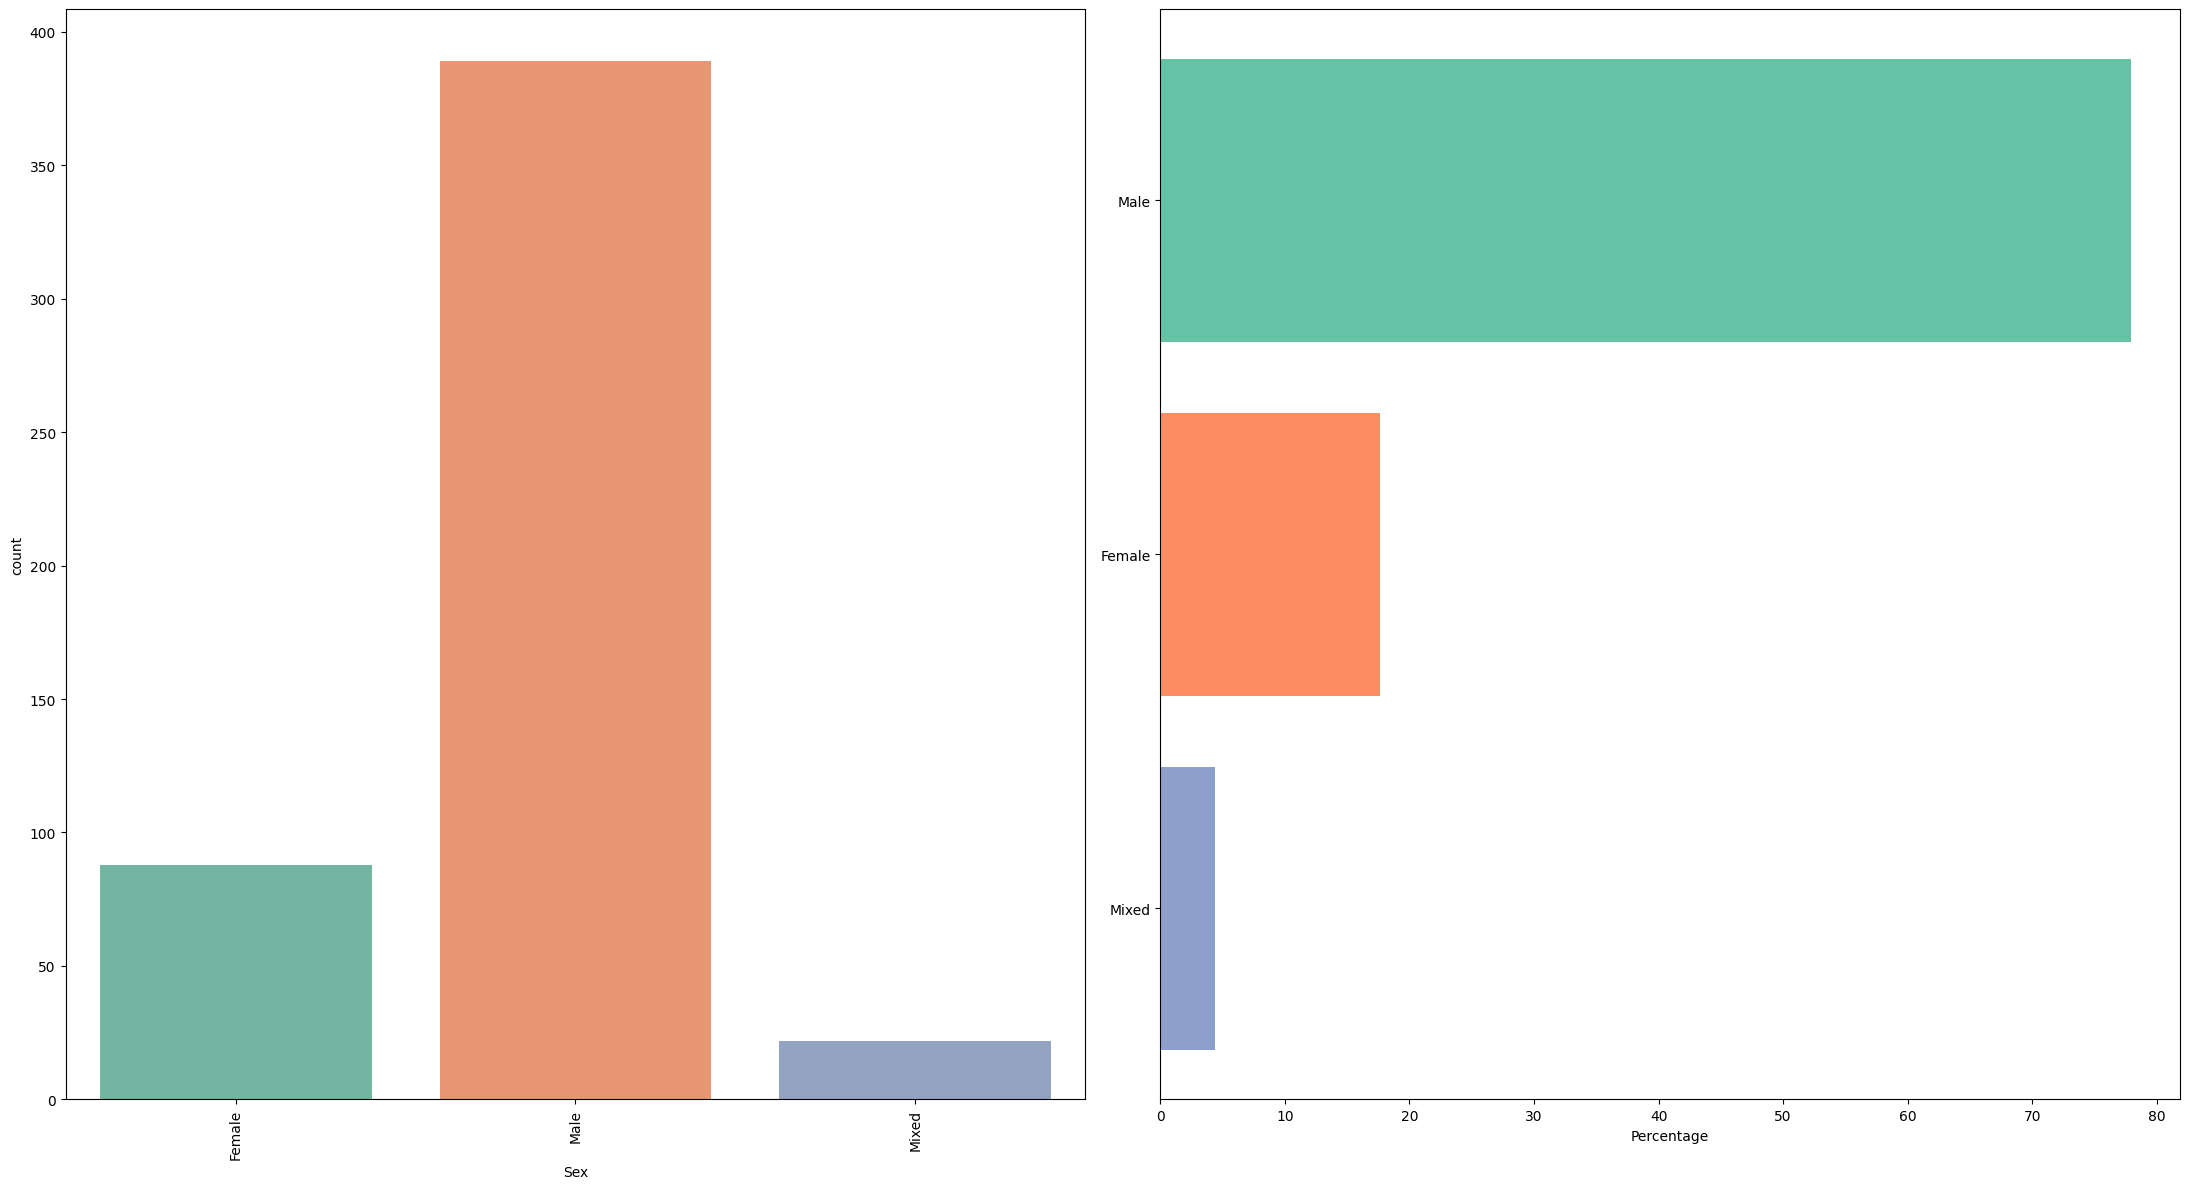

Unique vales 3
Missing values in Sex 0


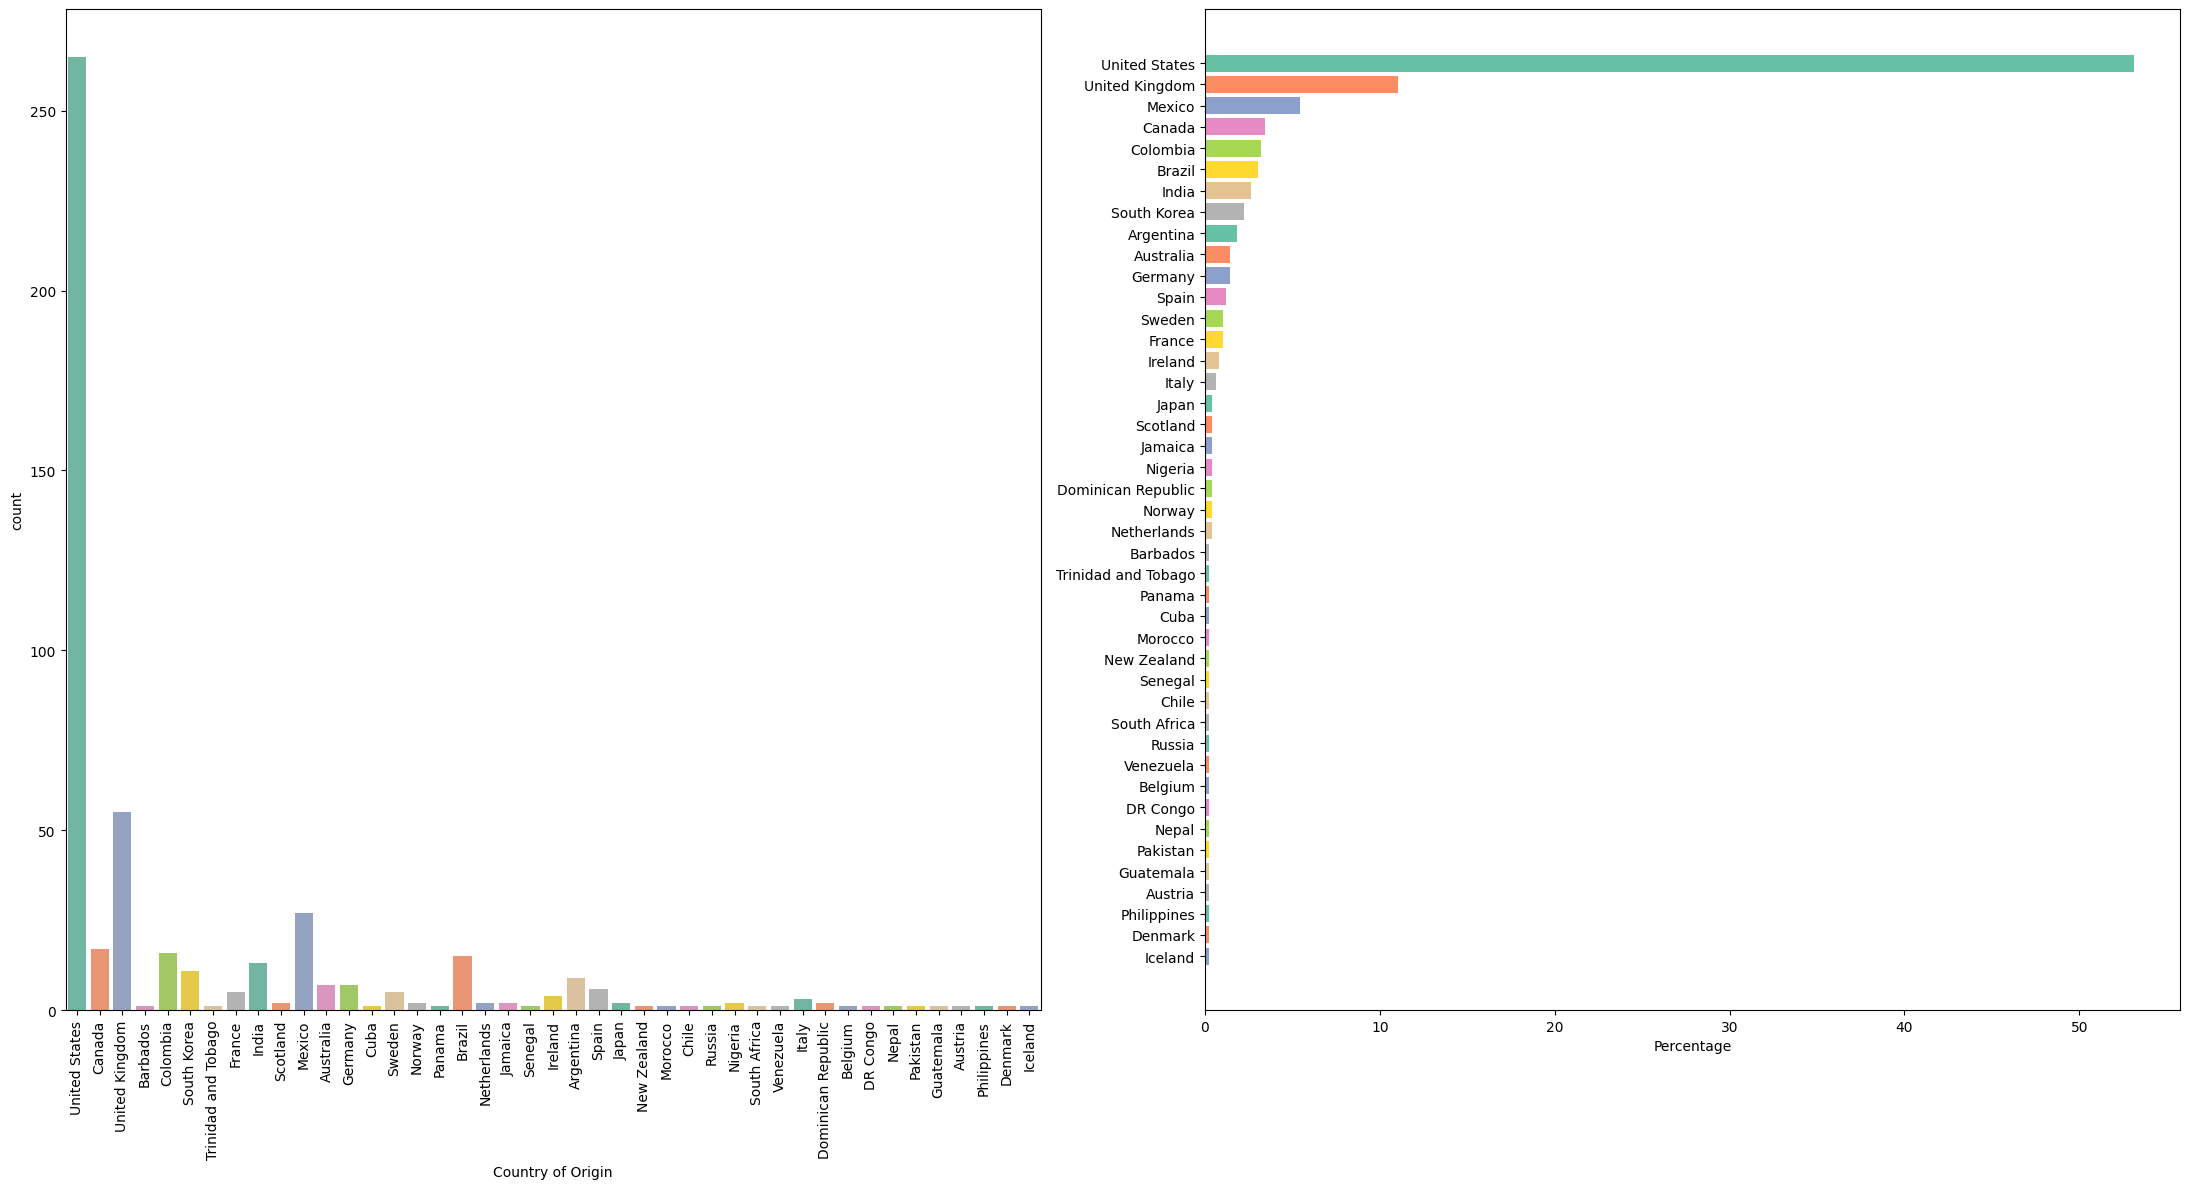

Unique vales 43
Missing values in Country of Origin 0


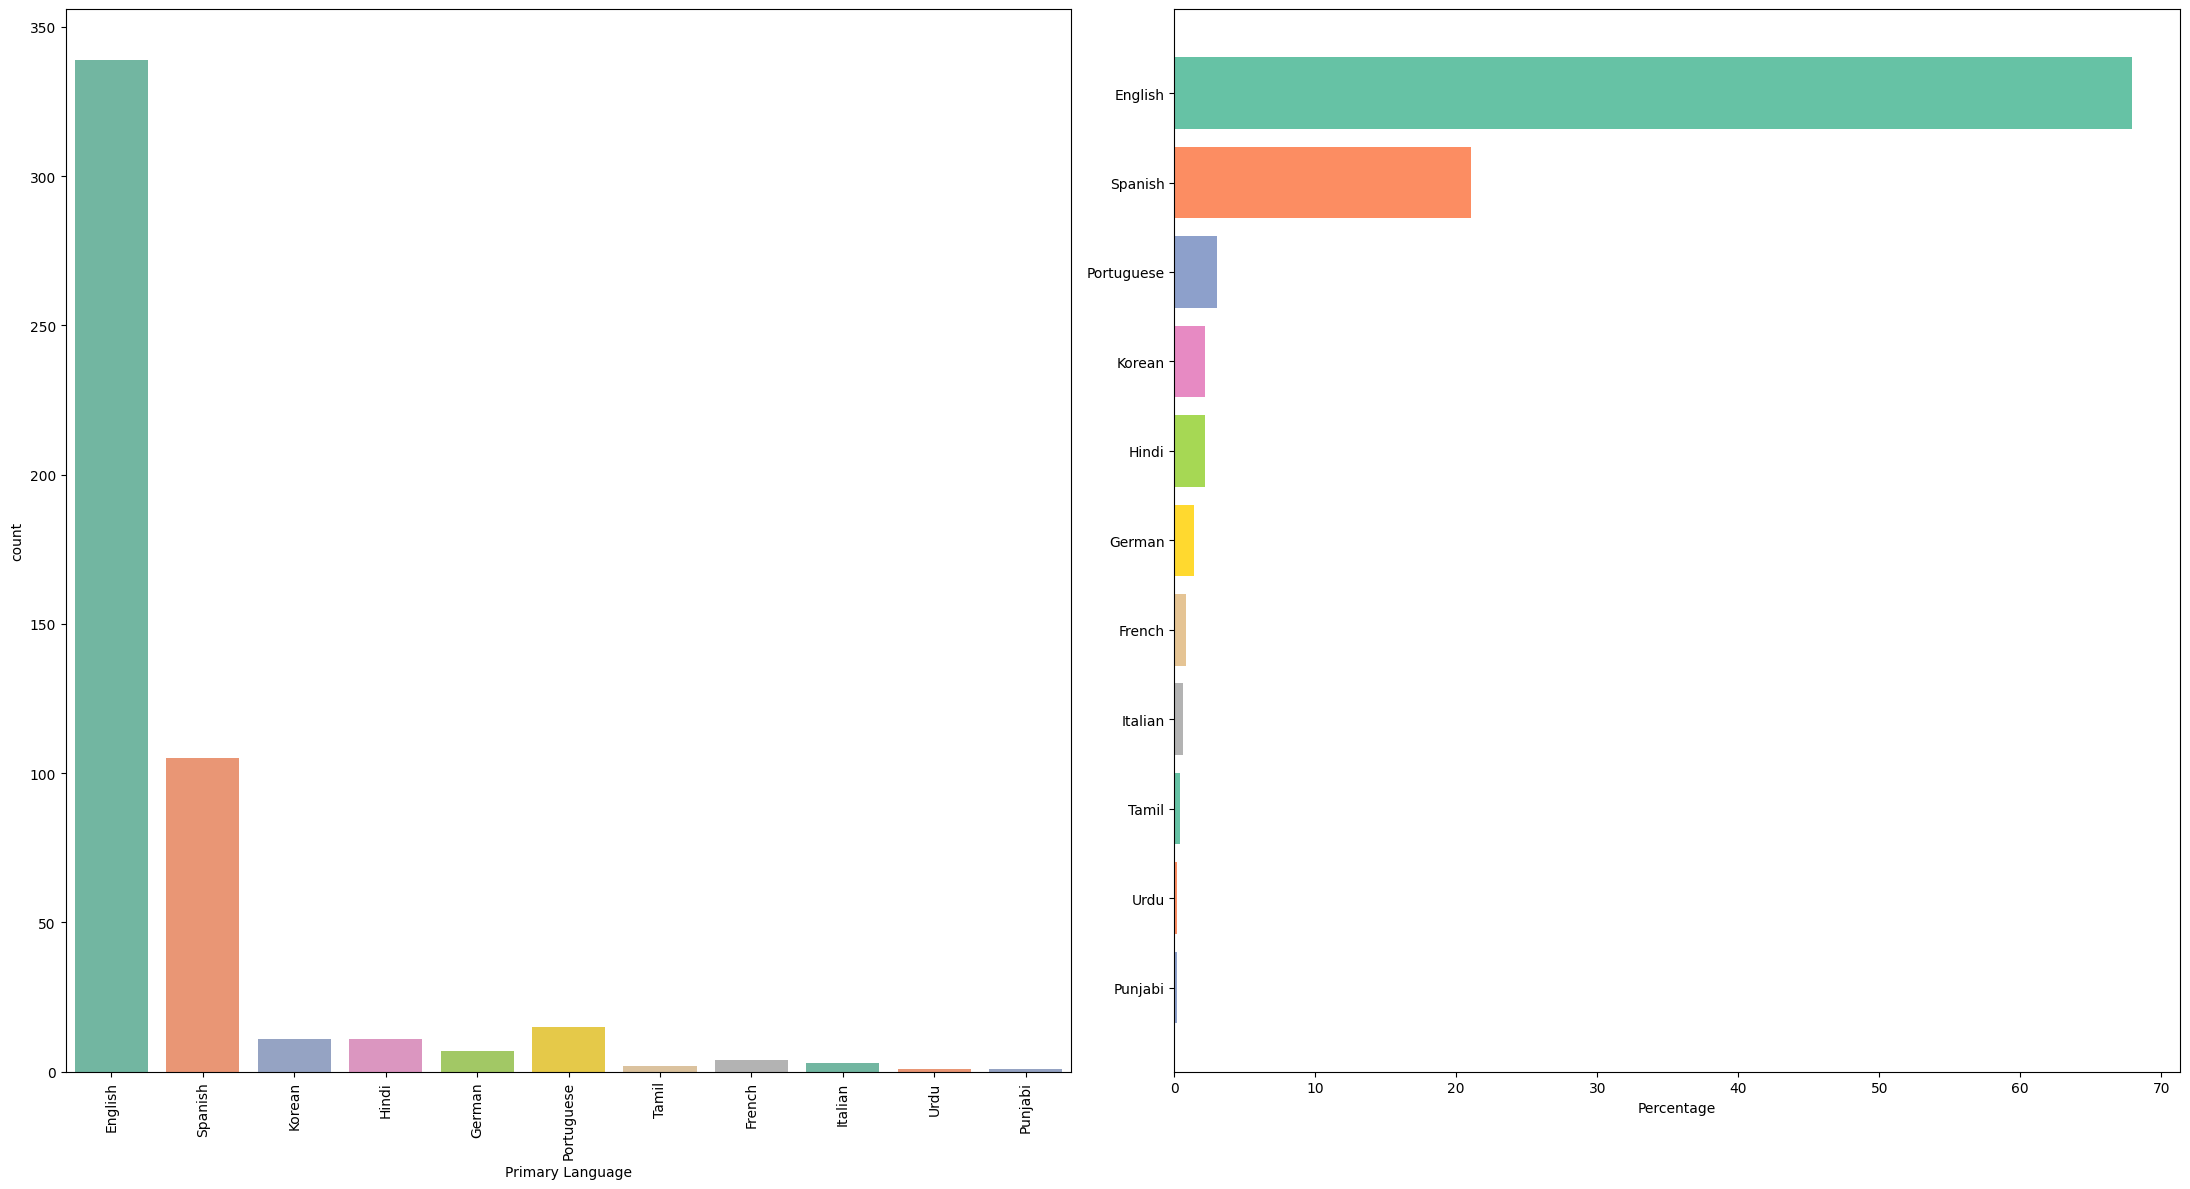

Unique vales 11
Missing values in Primary Language 0


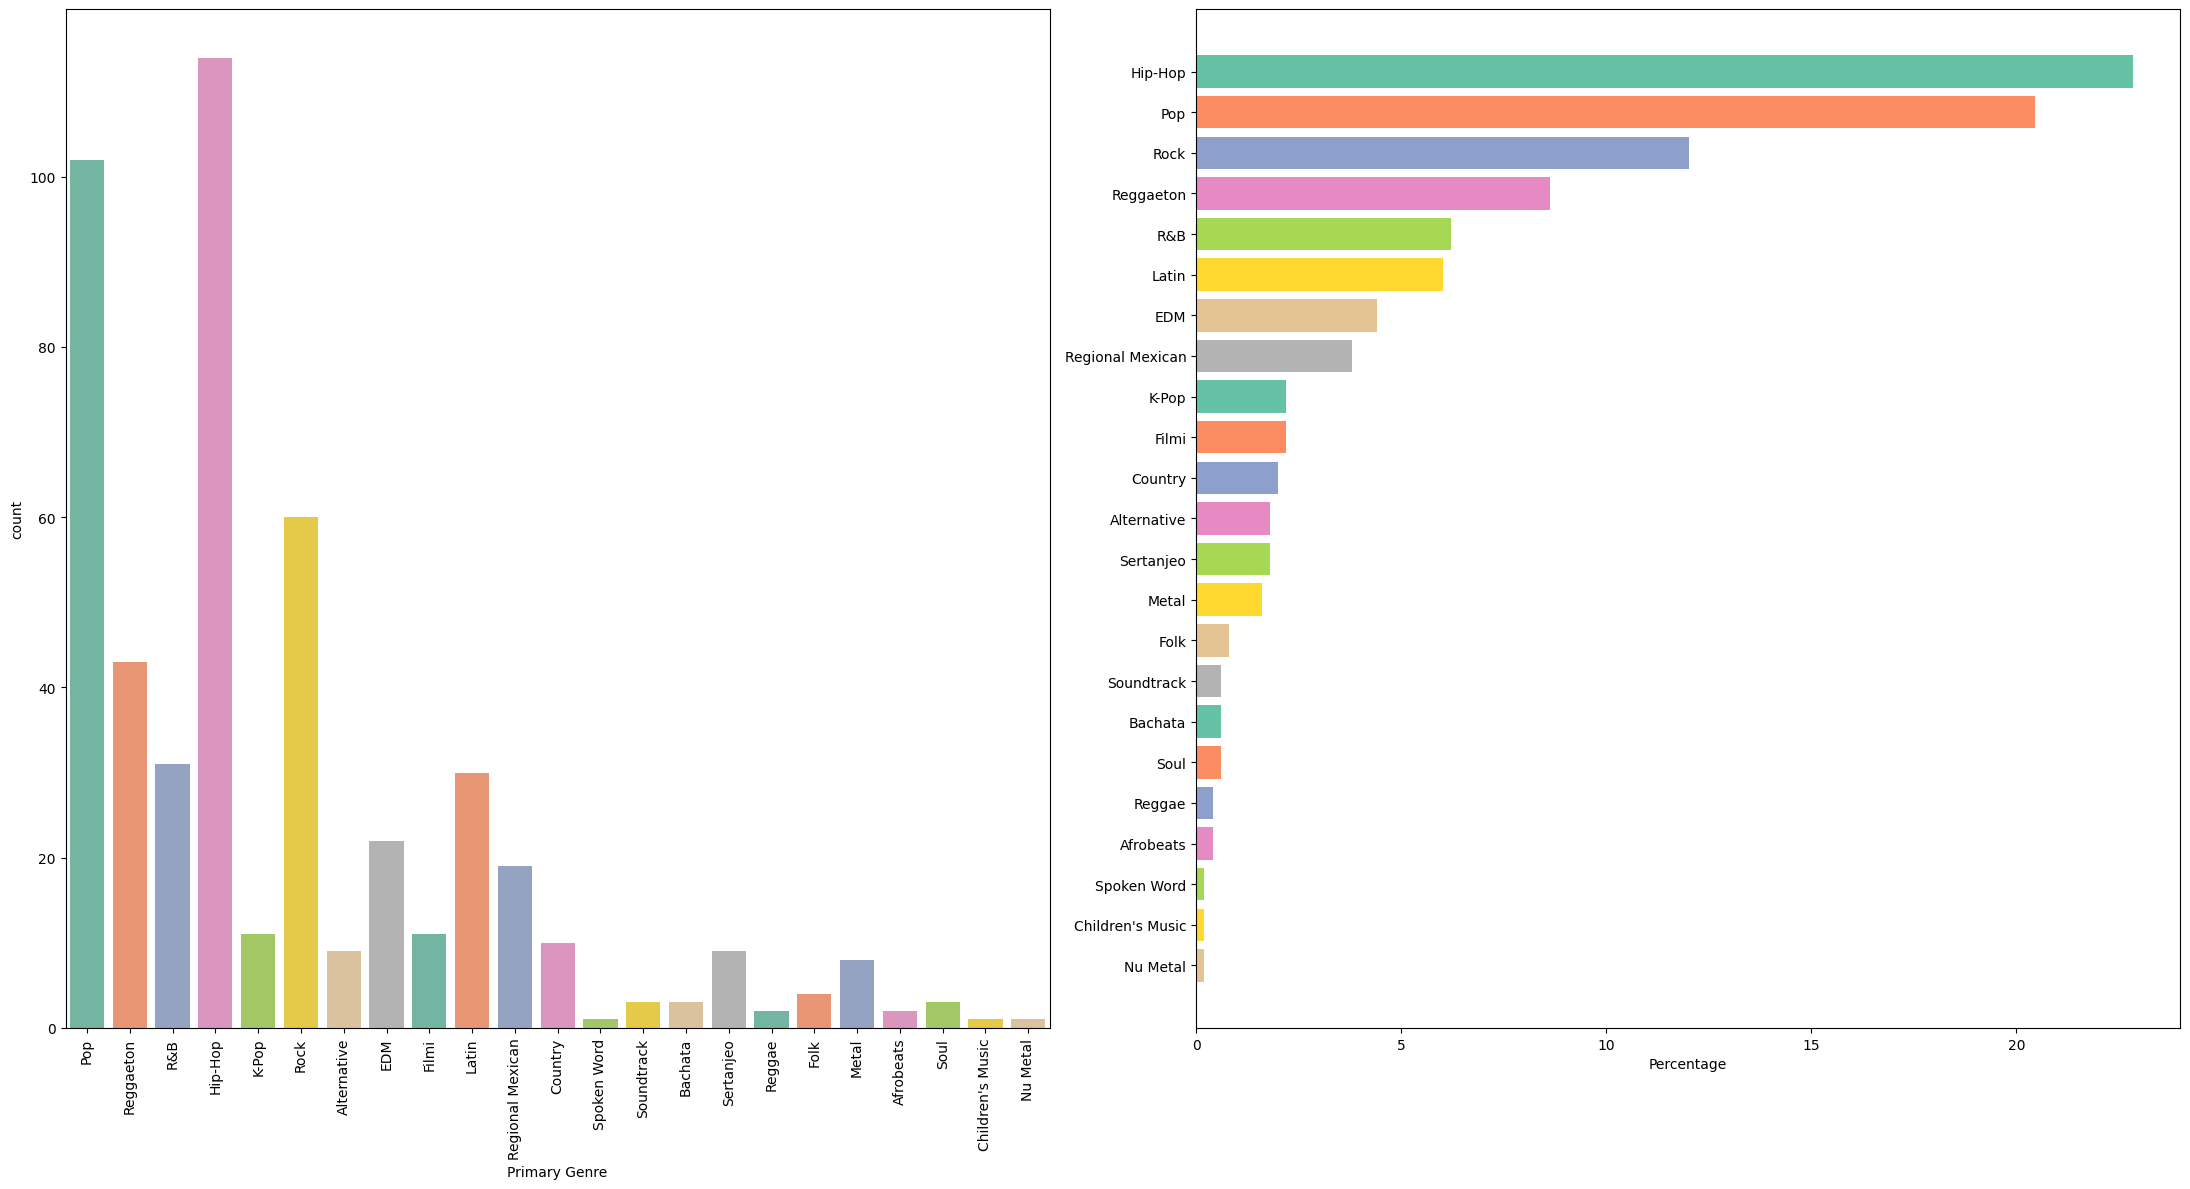

Unique vales 23
Missing values in Primary Genre 0


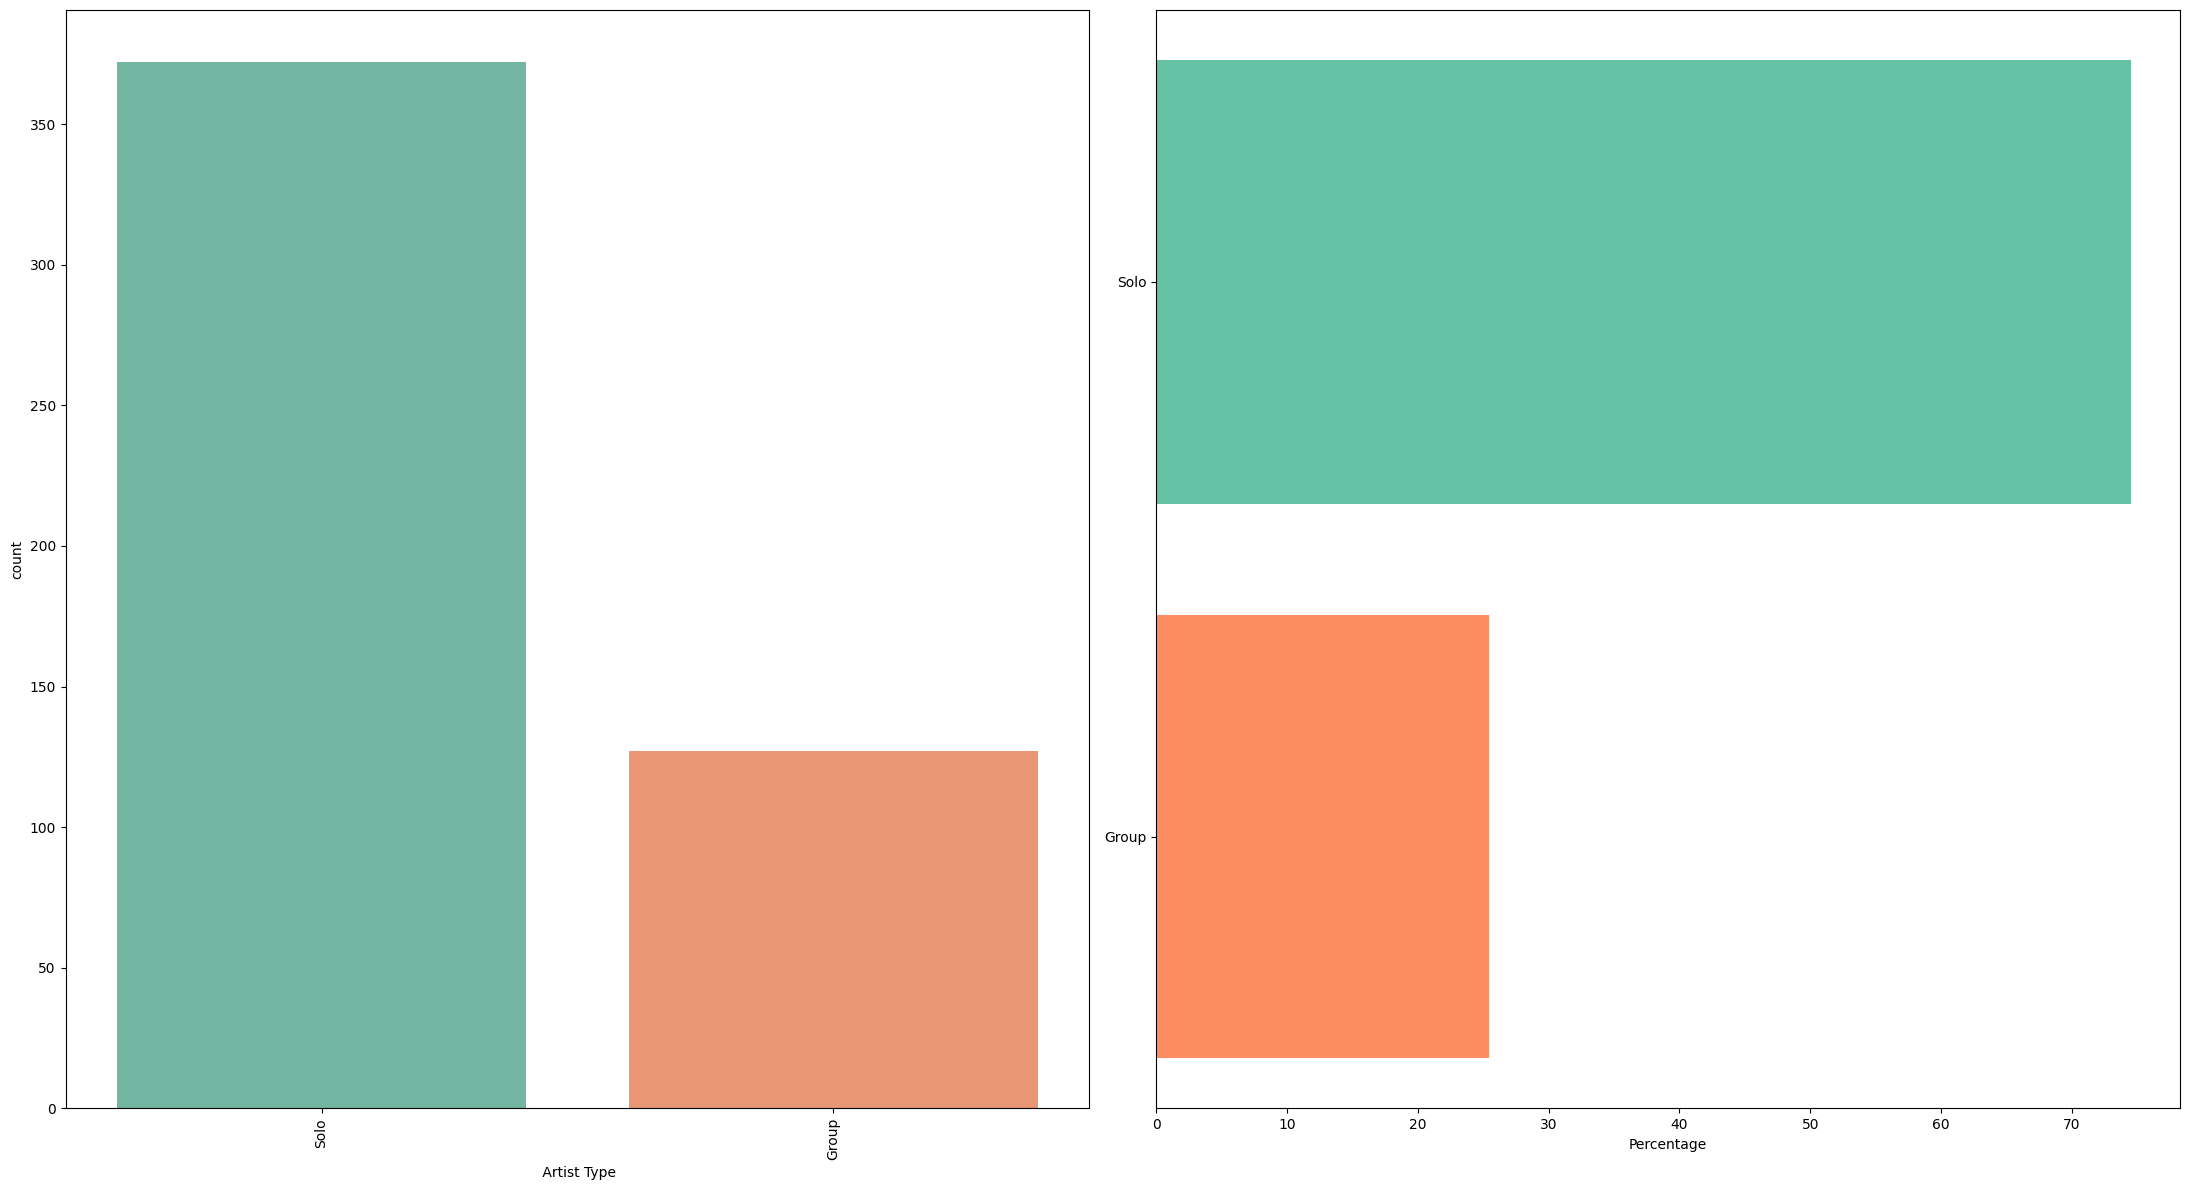

Unique vales 2
Missing values in  Artist Type 0


In [12]:
# 'Artist Name' is removed 
categoric = ['Sex', 'Country of Origin', 'Primary Language', 'Primary Genre', ' Artist Type'] 

for category in categoric:
    plt.figure(figsize=(22, 12))
    plt.subplot(1, 2, 1)
    sns.countplot(x=category, data=df, hue=category, palette='Set2')
    plt.xticks(rotation=90)    
    plt.subplot(1, 2, 2)
    counts = df[category].value_counts(normalize=True)*100
    plt.barh(y=counts.index, width=counts.values , color = sns.color_palette('Set2',len(counts)))
    plt.xlabel('Percentage')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print("Unique vales" , df[category].nunique())
    print(f"Missing values in {category}" , df[category].isna().sum())

>Renaming the columns for an ease of Querying

In [13]:
df.columns = df.columns.str.replace(r'[^a-zA-Z0-9_]', '', regex=True)

In [14]:
df.tail()

,ArtistName,Sex,CountryofOrigin,PrimaryLanguage,PrimaryGenre,ArtistType,DebutYear,TotalStreamsinmillions,LeadStreamsinmillions,FeatureStreamsinmillions,SoloStreamsinmillions,ofSoloStreams,CollaborativeStreamsinmillions,ofCollaborativeStreams
495,The Cure,Male,United Kingdom,English,Rock,Group,1979,7034.1,7035.0,3.3,6940.1,98.663653,94.0,1.336347
496,The Marías,Mixed,United States,English,Pop,Group,2017,7029.1,5774.4,1261.4,5705.9,81.175399,1323.2,18.824601
497,Limp Bizkit,Male,United States,English,Nu Metal,Group,1997,7018.9,7018.4,5.4,6806.0,96.966761,212.9,3.033239
498,Korn,Male,United States,English,Metal,Group,1994,6976.4,4188.4,2798.5,6414.9,91.951436,561.5,8.048564
499,Omar Courtz,Male,United States,Spanish,Reggaeton,Solo,2017,6972.0,6956.0,20.3,1876.2,26.910499,5095.8,73.089501


# Using **SQL** to do the further analysis

In [15]:
import sqlite3
conn = sqlite3.connect("artists.db")

In [16]:
df.to_sql(
    "streams",
    conn,
    if_exists="replace",
    index=False
)
print("connected sucessfully")

connected sucessfully


In [17]:
query = """
SELECT *
FROM streams
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

result

,ArtistName,Sex,CountryofOrigin,PrimaryLanguage,PrimaryGenre,ArtistType,DebutYear,TotalStreamsinmillions,LeadStreamsinmillions,FeatureStreamsinmillions,SoloStreamsinmillions,ofSoloStreams,CollaborativeStreamsinmillions,ofCollaborativeStreams
0,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
1,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
2,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
3,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970
4,Ariana Grande,Female,United States,English,Pop,Solo,2013,68298.9,57097.5,11201.4,41615.5,60.931435,26683.4,39.068565


In [18]:
for country in df["CountryofOrigin"].dropna().unique() :
    query = f"""
    SELECT ArtistName 
    FROM streams
    WHERE CountryofOrigin = '{country}'
    ORDER BY TotalStreamsinmillions DESC LIMIT 5;
    """
    print(f"Top 5 Artist with most streams in  {country}" )
    result = pd.read_sql_query(query, conn)
    print(result)
    print("*"*100)

Top 5 Artist with most streams in  United States
      ArtistName
0   Taylor Swift
1      Bad Bunny
2  Ariana Grande
3   Travis Scott
4     Kanye West
****************************************************************************************************
Top 5 Artist with most streams in  Canada
      ArtistName
0     The Weeknd
1  Justin Bieber
2   Shawn Mendes
3     Tate McRae
4     Tory Lanez
****************************************************************************************************
Top 5 Artist with most streams in  United Kingdom
     ArtistName
0    Ed Sheeran
1      Coldplay
2      Dua Lipa
3     21 Savage
4  Harry Styles
****************************************************************************************************
Top 5 Artist with most streams in  Barbados
  ArtistName
0    Rihanna
****************************************************************************************************
Top 5 Artist with most streams in  Colombia
  ArtistName
0   J Balvin
1    KAROL G
2 

In [19]:
nofemale = [] 
for country in df['CountryofOrigin'].dropna().unique():
    query = f"""SELECT ArtistName as " "
             FROM streams 
             WHERE CountryofOrigin = '{country}' and Sex = 'Female'
             ORDER BY TotalStreamsinmillions DESC LIMIT 5 ;"""
    result = pd.read_sql_query(query,conn)
    if result.empty: 
        nofemale.append(country)
        continue
    print(f"Top 5 artists of {country} are : " , result ,"\n")
print("\nCountry with no female singers are : " , nofemale)

Top 5 artists of United States are :                  
0   Taylor Swift
1  Ariana Grande
2  Billie Eilish
3   Lana Del Rey
4            SZA 

Top 5 artists of Canada are :                  
0     Tate McRae
1   Alessia Cara
2  Avril Lavigne
3  Nelly Furtado
4    Céline Dion 

Top 5 artists of United Kingdom are :                   
0        Dua Lipa
1           Adele
2  Ellie Goulding
3      Charli xcx
4      Anne-Marie 

Top 5 artists of Barbados are :            
0  Rihanna 

Top 5 artists of Colombia are :               
0     KAROL G
1     Shakira
2  Kali Uchis 

Top 5 artists of South Korea are :              
0  BLACKPINK
1      TWICE
2     JENNIE
3   NewJeans 

Top 5 artists of Trinidad and Tobago are :                
0  Nicki Minaj 

Top 5 artists of India are :                   
0  Shreya Ghoshal
1     Alka Yagnik 

Top 5 artists of Australia are :        
0  Sia 

Top 5 artists of Germany are :                    
0  Bibi Blocksberg 

Top 5 artists of Cuba are :            